# Notebook 02: Split Data into Train/Dev/Test Sets

## Learning Goals
- Understand why we split data into train/dev/test sets
- Learn about overfitting and how splits prevent it
- Implement random splitting
- Understand stratified splitting for better balance
- Verify that splits are representative

## Why Do We Split Data?

Imagine you're a student preparing for a final exam. If the teacher gave you the **exact questions** that would be on the exam while you studied, you might memorize those specific answers but not actually learn the broader concepts. Then, if the teacher changed even one question, you'd struggle.

The same thing happens with AI systems! If we use the same data to both **train** (develop) our judge and **test** (evaluate) it, we risk **overfitting** - making a judge that works great on our specific examples but fails on new, unseen data.

### The Three Sets:

1. **Train Set (10-20%)**: Examples we can use freely for developing our judge
   - Use these for few-shot examples in your prompt
   - Study these to understand patterns
   - It's okay to "memorize" these - they're like your study materials

2. **Dev Set (40%)**: Examples we use to iteratively improve
   - Test your judge prompt changes here
   - Measure performance and iterate
   - Use to decide "does this change help or hurt?"
   - You'll look at this a lot, but don't put specific examples in your prompt

3. **Test Set (40-50%)**: The final exam
   - **Look at this LAST** and **only once**
   - Final check that your judge generalizes well
   - Protects against overfitting to the dev set
   - The ultimate test of whether your judge will work in production

### Key Principle:
**The test set simulates real production data** - data your judge has NEVER seen before. If your judge performs well on the test set, you can be confident it will perform well on real user queries.

## Step 1: Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
# This means you'll get the same random split each time you run the notebook
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the labeled data
labeled_data = pd.read_csv('../../data/labeled_traces.csv')

print(f"Loaded {len(labeled_data)} labeled examples")
print(f"Columns: {list(labeled_data.columns)}")

Loaded 101 labeled examples
Columns: ['query', 'dietary_restriction', 'response', 'success', 'error', 'trace_id', 'query_id', 'label', 'reasoning', 'confidence', 'labeled']


## Step 2: Decide on Split Percentages

From the walkthrough, Isaac suggested:
- **Train**: 10-20% (we'll use 15%)
- **Dev**: 40%
- **Test**: 45-50% (we'll use 45%)

Why these percentages?
- **Small train set**: We only need a few good examples for few-shot learning (2-4 examples)
- **Larger dev/test sets**: We want high confidence in our evaluation metrics
- **Test slightly smaller than dev**: We iterate on dev more, so we want it robust

### 🤔 When might you change these percentages?
- If you have **very little labeled data** (< 50 examples): Use larger train set to get enough examples
- If you have **tons of data** (> 1000 examples): Can use smaller percentages since absolute numbers are large
- If a specific dietary restriction is **underrepresented**: May need stratified splitting (we'll cover this)

In [3]:
# Define split percentages
TRAIN_PERCENT = 0.15
DEV_PERCENT = 0.40
TEST_PERCENT = 0.45

# Verify they sum to 1.0
total = TRAIN_PERCENT + DEV_PERCENT + TEST_PERCENT
print(f"Split percentages: Train={TRAIN_PERCENT:.0%}, Dev={DEV_PERCENT:.0%}, Test={TEST_PERCENT:.0%}")
print(f"Total: {total:.2f} (should be 1.0)")

# Calculate expected sizes
total_size = len(labeled_data)
train_size = int(total_size * TRAIN_PERCENT)
dev_size = int(total_size * DEV_PERCENT)
test_size = total_size - train_size - dev_size  # Remainder goes to test

print(f"\nExpected sizes:")
print(f"  Train: {train_size} examples")
print(f"  Dev: {dev_size} examples")
print(f"  Test: {test_size} examples")
print(f"  Total: {train_size + dev_size + test_size} (should equal {total_size})")

Split percentages: Train=15%, Dev=40%, Test=45%
Total: 1.00 (should be 1.0)

Expected sizes:
  Train: 15 examples
  Dev: 40 examples
  Test: 46 examples
  Total: 101 (should equal 101)


## Step 3: Random Split (Simple Approach)

The simplest approach is to randomly shuffle the data and split it into three parts.

### How it works:
1. Shuffle all examples randomly
2. Take first 15% → Train
3. Take next 40% → Dev  
4. Take remaining 45% → Test

### Pros:
- Simple and fast
- Works well if you have enough data

### Cons:
- Might create imbalanced splits (e.g., train has mostly "vegan", test has mostly "keto")
- Random chance could put all the tricky edge cases in one set

In [4]:
# Shuffle the data
shuffled_data = labeled_data.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# Split into train, dev, test
# Method: Use array slicing to divide the shuffled data
train_end = train_size
dev_end = train_size + dev_size

train_set = shuffled_data[:train_end]
dev_set = shuffled_data[train_end:dev_end]
test_set = shuffled_data[dev_end:]

print("Random split completed!")
print(f"  Train set: {len(train_set)} examples")
print(f"  Dev set: {len(dev_set)} examples")
print(f"  Test set: {len(test_set)} examples")

Random split completed!
  Train set: 15 examples
  Dev set: 40 examples
  Test set: 46 examples


## Step 4: Verify Split Quality

Before we commit to this split, let's check if it's **representative**. We want to make sure:
1. PASS/FAIL ratios are similar across all three sets
2. Dietary restrictions are distributed evenly
3. No single set is "too easy" or "too hard"

This is like checking that your study materials, practice tests, and final exam all cover the same topics!

In [5]:
# Function to print distribution for a dataset
def print_distribution(dataset, name):
    print(f"\n{'='*60}")
    print(f"{name} Set Distribution")
    print(f"{'='*60}")
    
    # Label distribution
    label_dist = dataset['label'].value_counts()
    label_pct = dataset['label'].value_counts(normalize=True) * 100
    print(f"\n📊 Label Distribution:")
    for label in ['PASS', 'FAIL']:
        if label in label_dist.index:
            count = label_dist[label]
            pct = label_pct[label]
            print(f"  {label}: {count} ({pct:.1f}%)")
    
    # Dietary restriction distribution
    restriction_dist = dataset['dietary_restriction'].value_counts()
    print(f"\n🥗 Top 5 Dietary Restrictions:")
    for restriction, count in restriction_dist.head().items():
        pct = (count / len(dataset)) * 100
        print(f"  {restriction}: {count} ({pct:.1f}%)")

# Print distributions for all three sets
print_distribution(train_set, "TRAIN")
print_distribution(dev_set, "DEV")
print_distribution(test_set, "TEST")


TRAIN Set Distribution

📊 Label Distribution:
  PASS: 11 (73.3%)
  FAIL: 4 (26.7%)

🥗 Top 5 Dietary Restrictions:
  gluten-free: 3 (20.0%)
  pescatarian: 3 (20.0%)
  low-carb: 2 (13.3%)
  vegetarian: 2 (13.3%)
  paleo: 2 (13.3%)

DEV Set Distribution

📊 Label Distribution:
  PASS: 31 (77.5%)
  FAIL: 9 (22.5%)

🥗 Top 5 Dietary Restrictions:
  low-carb: 7 (17.5%)
  paleo: 5 (12.5%)
  keto: 5 (12.5%)
  vegetarian: 5 (12.5%)
  diabetic-friendly: 4 (10.0%)

TEST Set Distribution

📊 Label Distribution:
  PASS: 33 (71.7%)
  FAIL: 13 (28.3%)

🥗 Top 5 Dietary Restrictions:
  vegetarian: 11 (23.9%)
  vegan: 6 (13.0%)
  gluten-free: 5 (10.9%)
  dairy-free: 4 (8.7%)
  raw vegan: 3 (6.5%)


### Visual Comparison of Splits


COMPARISON ACROSS SPLITS
  Set  PASS (%)  FAIL (%)  Size
Train 73.333333 26.666667    15
  Dev 77.500000 22.500000    40
 Test 71.739130 28.260870    46


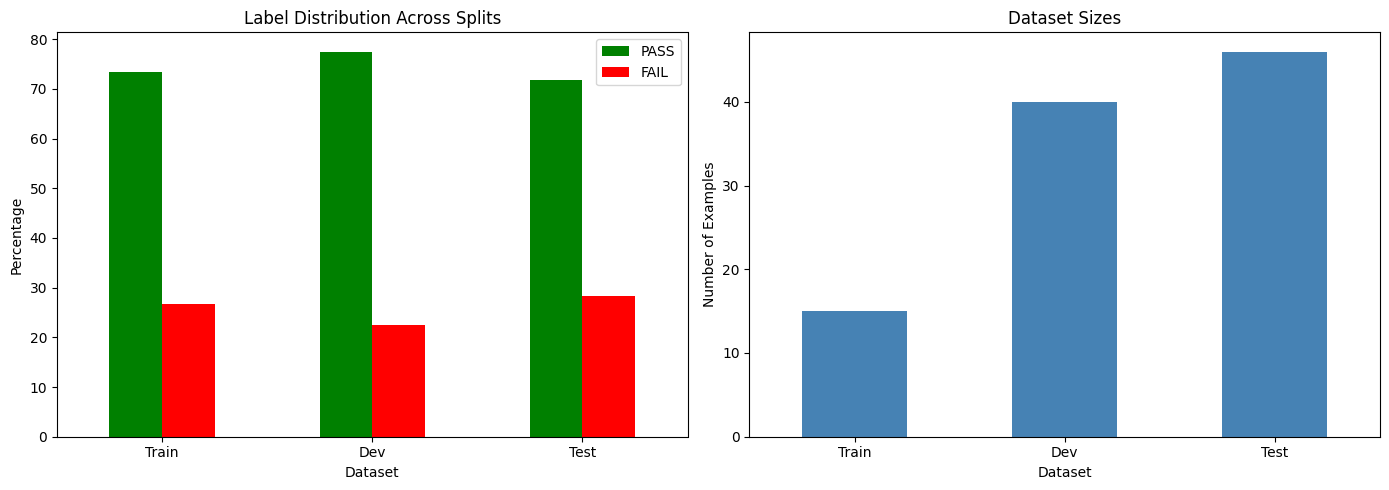

In [6]:
# Create a comparison DataFrame
comparison_data = []

for name, dataset in [('Train', train_set), ('Dev', dev_set), ('Test', test_set)]:
    pass_pct = (dataset['label'] == 'PASS').sum() / len(dataset) * 100
    fail_pct = (dataset['label'] == 'FAIL').sum() / len(dataset) * 100
    
    comparison_data.append({
        'Set': name,
        'PASS (%)': pass_pct,
        'FAIL (%)': fail_pct,
        'Size': len(dataset)
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("COMPARISON ACROSS SPLITS")
print("="*60)
print(comparison_df.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Label distribution
comparison_df.set_index('Set')[['PASS (%)', 'FAIL (%)']].plot(
    kind='bar', 
    ax=ax1, 
    color=['green', 'red']
)
ax1.set_title('Label Distribution Across Splits')
ax1.set_ylabel('Percentage')
ax1.set_xlabel('Dataset')
ax1.legend(['PASS', 'FAIL'])
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Plot 2: Set sizes
comparison_df.set_index('Set')['Size'].plot(
    kind='bar',
    ax=ax2,
    color='steelblue'
)
ax2.set_title('Dataset Sizes')
ax2.set_ylabel('Number of Examples')
ax2.set_xlabel('Dataset')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


DIETARY RESTRICTION DISTRIBUTION ACROSS SPLITS


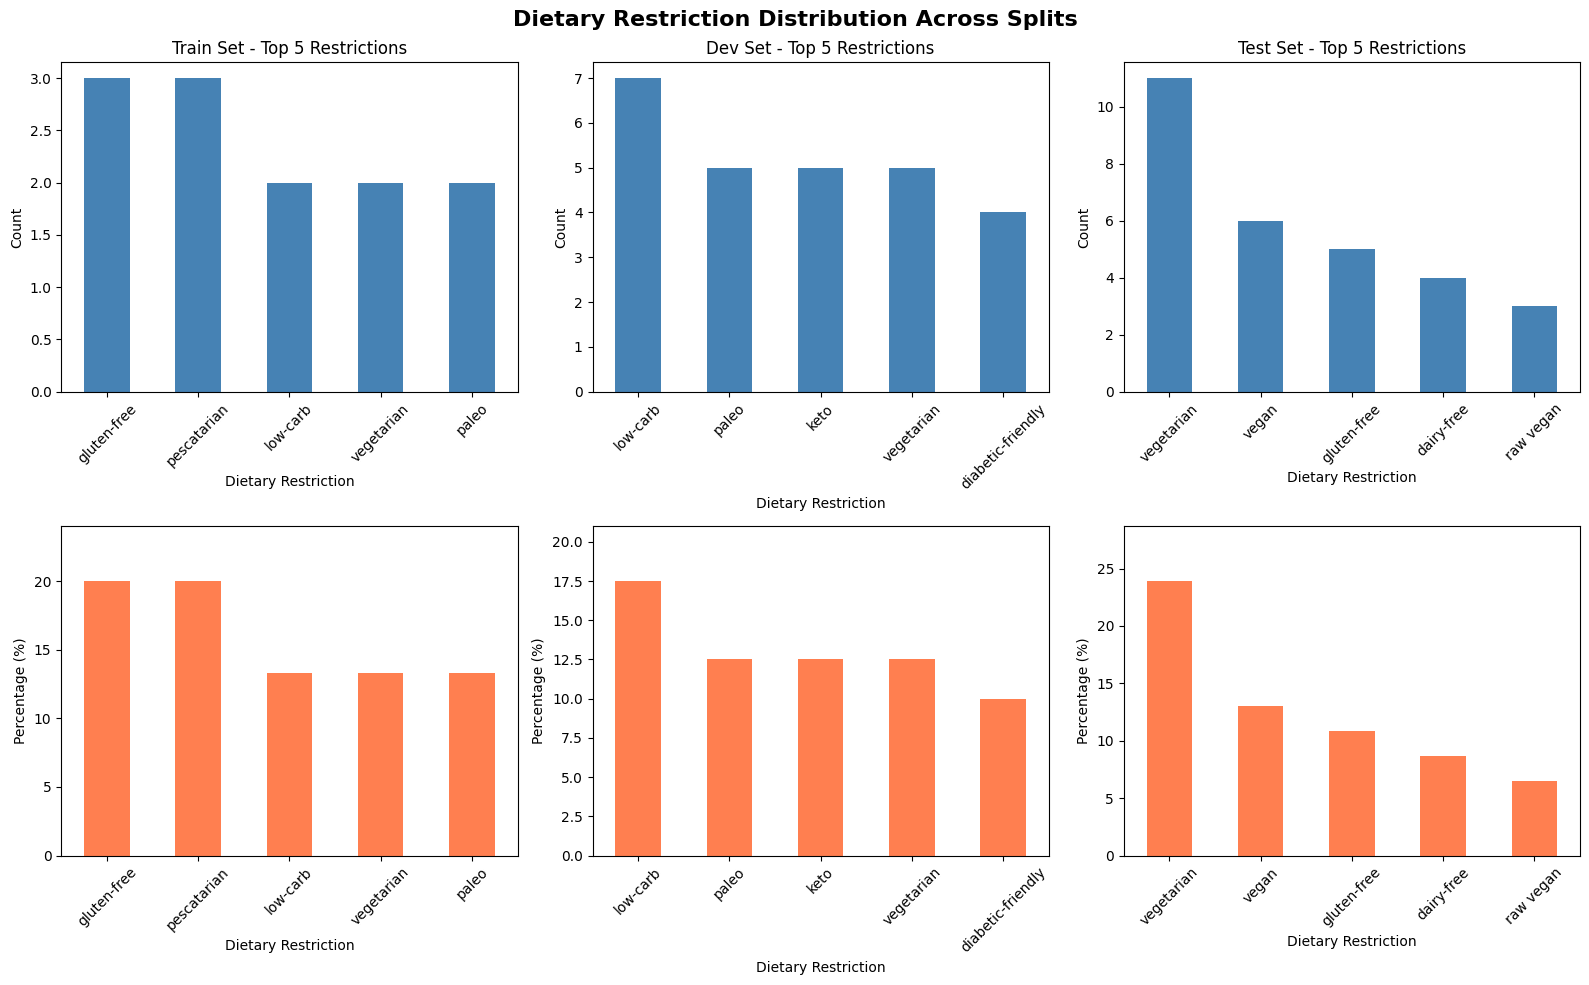


Top 5 Dietary Restrictions - Percentage Comparison:
                     Full Dataset  Train   Dev  Test
dietary_restriction                                 
dairy-free                    NaN    NaN   NaN   8.7
diabetic-friendly             NaN    NaN  10.0   NaN
gluten-free                   9.9   20.0   NaN  10.9
keto                          NaN    NaN  12.5   NaN
low-carb                     10.9   13.3  17.5   NaN
paleo                         9.9   13.3  12.5   NaN
pescatarian                   NaN   20.0   NaN   NaN
raw vegan                     NaN    NaN   NaN   6.5
vegan                        10.9    NaN   NaN  13.0
vegetarian                   17.8   13.3  12.5  23.9


In [7]:
# Visualize dietary restriction distribution across splits
print("\n" + "="*60)
print("DIETARY RESTRICTION DISTRIBUTION ACROSS SPLITS")
print("="*60)

# Combine all splits with a label for which set they're from
train_labeled = train_set.copy()
train_labeled['split'] = 'Train'

dev_labeled = dev_set.copy()
dev_labeled['split'] = 'Dev'

test_labeled = test_set.copy()
test_labeled['split'] = 'Test'

all_splits = pd.concat([train_labeled, dev_labeled, test_labeled])

# Get top 5 most common dietary restrictions from full dataset
top_restrictions = labeled_data['dietary_restriction'].value_counts().head(5).index

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Dietary Restriction Distribution Across Splits', fontsize=16, fontweight='bold')

# For each split, create a bar chart
for idx, (name, dataset) in enumerate([('Train', train_set), ('Dev', dev_set), ('Test', test_set)]):
    # Top row: Count of each restriction
    ax = axes[0, idx]
    restriction_counts = dataset['dietary_restriction'].value_counts().head(5)
    restriction_counts.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{name} Set - Top 5 Restrictions')
    ax.set_ylabel('Count')
    ax.set_xlabel('Dietary Restriction')
    ax.tick_params(axis='x', rotation=45)
    
    # Bottom row: Percentage distribution
    ax = axes[1, idx]
    restriction_pct = dataset['dietary_restriction'].value_counts(normalize=True).head(5) * 100
    restriction_pct.plot(kind='bar', ax=ax, color='coral')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('Dietary Restriction')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, max(restriction_pct.max() * 1.2, 20))  # Set y-axis for better comparison

plt.tight_layout()
plt.show()

# Print comparison table
print("\nTop 5 Dietary Restrictions - Percentage Comparison:")
print("="*60)
comparison_table = pd.DataFrame({
    'Full Dataset': labeled_data['dietary_restriction'].value_counts(normalize=True).head(5) * 100,
    'Train': train_set['dietary_restriction'].value_counts(normalize=True).head(5) * 100,
    'Dev': dev_set['dietary_restriction'].value_counts(normalize=True).head(5) * 100,
    'Test': test_set['dietary_restriction'].value_counts(normalize=True).head(5) * 100
})
print(comparison_table.round(1))

In [8]:
# Complete analysis of ALL dietary restrictions across splits
print("="*80)
print("COMPLETE DIETARY RESTRICTION ANALYSIS - ALL RESTRICTIONS")
print("="*80)

# Get all unique dietary restrictions in the full dataset
all_restrictions = sorted(labeled_data['dietary_restriction'].unique())
print(f"\nTotal unique dietary restrictions: {len(all_restrictions)}\n")

# Create a comprehensive comparison table
restriction_comparison = pd.DataFrame()

for restriction in all_restrictions:
    restriction_comparison.loc[restriction, 'Full Dataset'] = (labeled_data['dietary_restriction'] == restriction).sum()
    restriction_comparison.loc[restriction, 'Train'] = (train_set['dietary_restriction'] == restriction).sum()
    restriction_comparison.loc[restriction, 'Dev'] = (dev_set['dietary_restriction'] == restriction).sum()
    restriction_comparison.loc[restriction, 'Test'] = (test_set['dietary_restriction'] == restriction).sum()

# Add percentage columns
for col in ['Full Dataset', 'Train', 'Dev', 'Test']:
    total = restriction_comparison[col].sum()
    restriction_comparison[f'{col} %'] = (restriction_comparison[col] / total * 100).round(1)

# Reorder columns: counts first, then percentages
cols_order = ['Full Dataset', 'Train', 'Dev', 'Test', 
              'Full Dataset %', 'Train %', 'Dev %', 'Test %']
restriction_comparison = restriction_comparison[cols_order]

# Sort by Full Dataset count (descending) to see most common first
restriction_comparison = restriction_comparison.sort_values('Full Dataset', ascending=False)

print("\nCOMPLETE DISTRIBUTION TABLE (Counts and Percentages):")
print("="*80)
print(restriction_comparison.to_string())

# Identify potential problems
print("\n" + "="*80)
print("⚠️  POTENTIAL ISSUES - Missing or Underrepresented Restrictions")
print("="*80)

issues_found = False

for restriction in all_restrictions:
    train_count = restriction_comparison.loc[restriction, 'Train']
    dev_count = restriction_comparison.loc[restriction, 'Dev']
    test_count = restriction_comparison.loc[restriction, 'Test']
    full_count = restriction_comparison.loc[restriction, 'Full Dataset']
    
    # Check for missing in any split
    if train_count == 0 or dev_count == 0 or test_count == 0:
        issues_found = True
        print(f"\n❌ {restriction}:")
        print(f"   Full Dataset: {full_count} | Train: {train_count} | Dev: {dev_count} | Test: {test_count}")
        print(f"   ⚠️  Missing from: ", end="")
        missing_from = []
        if train_count == 0:
            missing_from.append("Train")
        if dev_count == 0:
            missing_from.append("Dev")
        if test_count == 0:
            missing_from.append("Test")
        print(", ".join(missing_from))
    
    # Check for very low representation (only 1 example in a split)
    elif dev_count == 1 or test_count == 1:
        issues_found = True
        print(f"\n⚠️  {restriction}:")
        print(f"   Full Dataset: {full_count} | Train: {train_count} | Dev: {dev_count} | Test: {test_count}")
        print(f"   ⚠️  Only 1 example in: ", end="")
        low_rep = []
        if dev_count == 1:
            low_rep.append("Dev")
        if test_count == 1:
            low_rep.append("Test")
        print(", ".join(low_rep))

if not issues_found:
    print("\n✅ No issues found! All dietary restrictions are represented in all splits.")
else:
    print("\n" + "="*80)
    print("💡 RECOMMENDATION:")
    print("   Consider using STRATIFIED split (if you haven't already)")
    print("   Stratified splitting ensures all categories are represented proportionally.")

COMPLETE DIETARY RESTRICTION ANALYSIS - ALL RESTRICTIONS

Total unique dietary restrictions: 16


COMPLETE DISTRIBUTION TABLE (Counts and Percentages):
                   Full Dataset  Train  Dev  Test  Full Dataset %  Train %  Dev %  Test %
vegetarian                 18.0    2.0  5.0  11.0            17.8     13.3   12.5    23.9
low-carb                   11.0    2.0  7.0   2.0            10.9     13.3   17.5     4.3
vegan                      11.0    1.0  4.0   6.0            10.9      6.7   10.0    13.0
gluten-free                10.0    3.0  2.0   5.0             9.9     20.0    5.0    10.9
paleo                      10.0    2.0  5.0   3.0             9.9     13.3   12.5     6.5
keto                        7.0    1.0  5.0   1.0             6.9      6.7   12.5     2.2
diabetic-friendly           6.0    1.0  4.0   1.0             5.9      6.7   10.0     2.2
pescatarian                 6.0    3.0  1.0   2.0             5.9     20.0    2.5     4.3
dairy-free                  4.0    0.0

### 🤔 Evaluation Questions:

Look at the comparison above and think about:

1. **Are the PASS/FAIL percentages similar across all three sets?**
   - If train has 90% PASS but test has 50% PASS, that's a problem!
   - Ideally, they should be within ~5-10 percentage points of each other

2. **Are any dietary restrictions completely missing from a set?**
   - If "keto" only appears in test but not in train/dev, your judge won't learn about it

3. **Do the sizes look reasonable?**
   - Train should be smallest, dev and test should be larger

If everything looks good, we can proceed! If not, we might need **stratified splitting**.

## Step 5: Stratified Split (Advanced - Optional but Recommended)

**Stratified splitting** ensures that each set has the same **proportion** of each category.

### Example:
If your full dataset is:
- 60% vegan
- 30% gluten-free  
- 10% keto

Then stratified splitting ensures each set (train/dev/test) also has approximately 60/30/10 distribution.

### When to use it:
- When you have **imbalanced categories** (some dietary restrictions are rare)
- When you want **maximum confidence** that your splits are representative
- When you saw issues in the random split above

### How it works:
We'll use scikit-learn's `train_test_split` with the `stratify` parameter.

## Step 6: Choose Your Split

Now you need to decide: **Random split or Stratified split?**

### Decision Guide:
- ✅ **Use Stratified** if:
  - You saw significant imbalance in the random split
  - Some dietary restrictions are very rare
  - You want maximum confidence in your splits
  
- ✅ **Use Random** if:
  - The distributions looked similar across sets
  - You have plenty of examples for all categories
  - You want simplicity

**For this homework, I recommend using STRATIFIED split** to ensure good representation.

## Step 7: Save Your Splits

Now let's save these splits to CSV files so we can use them in later notebooks.

In [21]:
# ==============================================================================
# COMPLETE STRATIFIED SPLIT - Updated for datasets with duplicate queries
# ==============================================================================

print("Creating stratified splits by PASS/FAIL label...")
print("="*60)

# Stage 1: Split off train set (15%)
train_stratified, dev_test = train_test_split(
    labeled_data,
    test_size=(1 - TRAIN_PERCENT),
    stratify=labeled_data['label'],
    random_state=RANDOM_SEED
)

print(f"✓ Stage 1 complete: Train vs (Dev+Test)")
print(f"  Train: {len(train_stratified)} examples")
print(f"  Dev+Test: {len(dev_test)} examples")

# Stage 2: Split dev_test into dev and test
dev_fraction = DEV_PERCENT / (DEV_PERCENT + TEST_PERCENT)

dev_stratified, test_stratified = train_test_split(
    dev_test,
    test_size=(1 - dev_fraction),
    stratify=dev_test['label'],
    random_state=RANDOM_SEED
)

print(f"\n✓ Stage 2 complete: Dev vs Test")
print(f"  Dev: {len(dev_stratified)} examples")
print(f"  Test: {len(test_stratified)} examples")

# Check for actual row overlaps (this should be 0)
train_indices = set(train_stratified.index)
dev_indices = set(dev_stratified.index)
test_indices = set(test_stratified.index)

row_overlap = len(train_indices.intersection(dev_indices)) + \
              len(train_indices.intersection(test_indices)) + \
              len(dev_indices.intersection(test_indices))

print(f"\n" + "="*60)
print("VALIDATION CHECKS:")
print("="*60)
print(f"✓ Row overlaps: {row_overlap} (should be 0)")
print(f"✓ Total rows: {len(train_stratified) + len(dev_stratified) + len(test_stratified)} (should be 101)")

# Check query overlaps (this is EXPECTED due to dataset design)
train_queries = set(train_stratified['query'].values)
dev_queries = set(dev_stratified['query'].values)
test_queries = set(test_stratified['query'].values)

query_overlaps = len(train_queries.intersection(dev_queries)) + \
                 len(train_queries.intersection(test_queries)) + \
                 len(dev_queries.intersection(test_queries))

print(f"ℹ️  Query overlaps: {query_overlaps} (expected due to duplicate queries in dataset)")

# Check PASS/FAIL distribution
print(f"\n" + "="*60)
print("PASS/FAIL DISTRIBUTION (should be balanced):")
print("="*60)
for name, dataset in [('Train', train_stratified), ('Dev', dev_stratified), ('Test', test_stratified)]:
    pass_pct = (dataset['label'] == 'PASS').sum() / len(dataset) * 100
    fail_pct = (dataset['label'] == 'FAIL').sum() / len(dataset) * 100
    print(f"{name:6s}: {pass_pct:5.1f}% PASS, {fail_pct:5.1f}% FAIL")

if row_overlap == 0:
    print("\n✅✅✅ Splits are valid! No row overlaps detected.")
    print("📝 Note: Query overlaps are expected in this dataset (same query, different contexts)")
    
    # Set final splits
    final_train = train_stratified
    final_dev = dev_stratified
    final_test = test_stratified
else:
    print("\n❌ ERROR: Row overlaps detected!")
    raise ValueError("Split validation failed")

Creating stratified splits by PASS/FAIL label...
✓ Stage 1 complete: Train vs (Dev+Test)
  Train: 15 examples
  Dev+Test: 86 examples

✓ Stage 2 complete: Dev vs Test
  Dev: 40 examples
  Test: 46 examples

VALIDATION CHECKS:
✓ Row overlaps: 0 (should be 0)
✓ Total rows: 101 (should be 101)
ℹ️  Query overlaps: 24 (expected due to duplicate queries in dataset)

PASS/FAIL DISTRIBUTION (should be balanced):
Train :  73.3% PASS,  26.7% FAIL
Dev   :  75.0% PASS,  25.0% FAIL
Test  :  73.9% PASS,  26.1% FAIL

✅✅✅ Splits are valid! No row overlaps detected.
📝 Note: Query overlaps are expected in this dataset (same query, different contexts)


In [22]:
# Save to CSV files in your my_work/data directory
output_dir = '../data'  # Relative path from notebooks/ to my_work/data/

train_path = f'{output_dir}/train_set.csv'
dev_path = f'{output_dir}/dev_set.csv'
test_path = f'{output_dir}/test_set.csv'

final_train.to_csv(train_path, index=False)
final_dev.to_csv(dev_path, index=False)
final_test.to_csv(test_path, index=False)

print("✅ Splits saved successfully!")
print(f"\nSaved files:")
print(f"  📁 {train_path}")
print(f"  📁 {dev_path}")
print(f"  📁 {test_path}")

✅ Splits saved successfully!

Saved files:
  📁 ../data/train_set.csv
  📁 ../data/dev_set.csv
  📁 ../data/test_set.csv


## Step 8: Final Verification

Let's do a final check to make sure everything is correct.

In [23]:
# Verify files were saved correctly by loading them back
train_loaded = pd.read_csv(train_path)
dev_loaded = pd.read_csv(dev_path)
test_loaded = pd.read_csv(test_path)

print("✅ Verification - Files loaded successfully")
print(f"\nLoaded sizes:")
print(f"  Train: {len(train_loaded)} examples")
print(f"  Dev: {len(dev_loaded)} examples")
print(f"  Test: {len(test_loaded)} examples")
print(f"  Total: {len(train_loaded) + len(dev_loaded) + len(test_loaded)}")

# Check for any overlap using a unique identifier (like query text)
# We'll check if the same queries appear in multiple sets
train_queries = set(train_loaded['query'].values)
dev_queries = set(dev_loaded['query'].values)
test_queries = set(test_loaded['query'].values)

train_dev_overlap = train_queries.intersection(dev_queries)
train_test_overlap = train_queries.intersection(test_queries)
dev_test_overlap = dev_queries.intersection(test_queries)

print(f"\n🔍 Checking for overlaps (using query text):")
print(f"  Train-Dev overlap: {len(train_dev_overlap)} (should be 0)")
print(f"  Train-Test overlap: {len(train_test_overlap)} (should be 0)")
print(f"  Dev-Test overlap: {len(dev_test_overlap)} (should be 0)")

if len(train_dev_overlap) == 0 and len(train_test_overlap) == 0 and len(dev_test_overlap) == 0:
    print("\n✅✅✅ Perfect! No overlaps detected. Your splits are clean!")
else:
    print("\n⚠️ WARNING: Real overlaps detected!")
    if len(train_dev_overlap) > 0:
        print(f"  Train-Dev has {len(train_dev_overlap)} duplicate queries")
    if len(train_test_overlap) > 0:
        print(f"  Train-Test has {len(train_test_overlap)} duplicate queries")
    if len(dev_test_overlap) > 0:
        print(f"  Dev-Test has {len(dev_test_overlap)} duplicate queries")

✅ Verification - Files loaded successfully

Loaded sizes:
  Train: 15 examples
  Dev: 40 examples
  Test: 46 examples
  Total: 101

🔍 Checking for overlaps (using query text):
  Train-Dev overlap: 4 (should be 0)
  Train-Test overlap: 7 (should be 0)
  Dev-Test overlap: 13 (should be 0)

⚠️ WARNING: Real overlaps detected!
  Train-Dev has 4 duplicate queries
  Train-Test has 7 duplicate queries
  Dev-Test has 13 duplicate queries


## Summary: What You've Learned

### Key Concepts:
1. **Train/Dev/Test Split**: Prevents overfitting by keeping test data completely unseen
2. **Overfitting**: When your system works great on training data but fails on new data
3. **Stratified Splitting**: Ensures balanced representation across categories
4. **Representativeness**: Your splits should reflect the distribution of the full dataset

### What You Created:
- ✅ Train set (~15%): For developing your judge prompt
- ✅ Dev set (~40%): For iterating and improving
- ✅ Test set (~45%): For final evaluation

### Best Practices:
1. **Never use test set examples in your prompt** - that's cheating!
2. **Look at test set only once** - at the very end
3. **Iterate on dev set freely** - that's what it's for
4. **Check distributions** - make sure splits are representative

### Next Steps:
Now that you have clean, representative splits, you're ready for **Notebook 03: Develop Judge Prompt**!

In the next notebook, you'll:
- Learn about few-shot prompting
- Select good training examples for your prompt
- Write your first judge prompt
- Test it manually on some dev examples
- Iterate to improve performance